In [6]:
import pandas as pd

df = pd.read_csv("/results/arity_results.csv")

print(df.groupby("language")["arity"].describe())

           count      mean       std  min  25%  50%  75%   max
language                                                      
English   5624.0  3.099218  1.823564  0.0  2.0  3.0  4.0  10.0
Hindi     2301.0  4.911777  1.125802  0.0  4.0  5.0  6.0   9.0
Japanese  1586.0  3.956494  1.259412  1.0  3.0  4.0  5.0  11.0


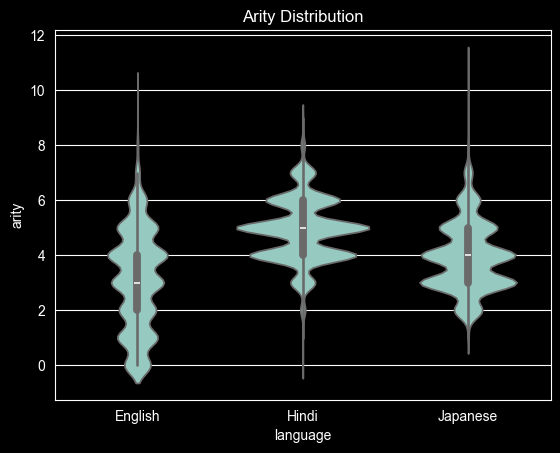

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=df, x="language", y="arity")
plt.title("Arity Distribution")
plt.show()

In [8]:
print(df.groupby("language").size())


language
English     5624
Hindi       2301
Japanese    1586
dtype: int64


In [11]:
import pandas as pd

df = pd.read_csv("/results/real_vs_random_metrics.csv")
df.head()

,language,real_arity,random_arity,real_depth,random_depth
0,English,3,2,3,5
1,English,5,3,2,5
2,English,6,3,2,5
3,English,6,3,2,3
4,English,4,2,4,7


In [12]:
df.groupby("language")[["real_arity","random_arity","real_depth","random_depth"]].mean()

,real_arity,random_arity,real_depth,random_depth
language,,,,
English,3.099218,2.288051,1.969061,2.785206
Hindi,4.911777,3.041286,2.625815,4.352021
Japanese,3.956494,2.914250,2.463430,3.814628


In [1]:
import pandas as pd

df = pd.read_csv("/Volumes/HODER/CODEX/CGS410/results/real_vs_random_metrics.csv")
df.head()

,language,real_arity,random_arity,real_depth,random_depth
0,English,3,2,3,5
1,English,5,3,2,5
2,English,6,3,2,5
3,English,6,3,2,3
4,English,4,2,4,7


In [2]:
from scipy.stats import mannwhitneyu

In [3]:
def run_mwu_test(df, metric, alternative):
    print(f"\n=== {metric.upper()} TEST ===")

    for lang in df["language"].unique():
        sub = df[df["language"] == lang]

        real = sub[f"real_{metric}"]
        random = sub[f"random_{metric}"]

        stat, p = mannwhitneyu(real, random, alternative=alternative)

        print(f"{lang}: p-value = {p:.6f}")

In [5]:
import numpy as np

def effect_size(df, metric):
    print(f"\n=== {metric.upper()} EFFECT SIZE ===")

    for lang in df["language"].unique():
        sub = df[df["language"] == lang]

        real = sub[f"real_{metric}"]
        random = sub[f"random_{metric}"]

        diff_mean = np.mean(real) - np.mean(random)
        diff_median = np.median(real) - np.median(random)

        print(f"{lang}: mean diff = {diff_mean:.3f}, median diff = {diff_median:.3f}")

In [6]:
effect_size(df, "depth")
effect_size(df, "arity")


=== DEPTH EFFECT SIZE ===
English: mean diff = -0.816, median diff = -1.000
Hindi: mean diff = -1.726, median diff = -1.000
Japanese: mean diff = -1.351, median diff = -2.000

=== ARITY EFFECT SIZE ===
English: mean diff = 0.811, median diff = 1.000
Hindi: mean diff = 1.870, median diff = 2.000
Japanese: mean diff = 1.042, median diff = 1.000
